# Regresão logística

# Conjuntos de dados
- `age` - idade do paciente em anos
- `sex` - sexobiológico (1 = masculino, 0 = feminino);
- `cp` - tipo de dor no peito: angina típica (1), atípica (2), não anginosa (3) ou assintomático (4);
- `trestbps` - pressão arterial em repouso em mmHg;
- `chol` - colesterol sérico total em mg/dl;
- `fbs` - glicemia em jejum acima de 120 mg/dl (1 = sim, 0 = não);
- `restecg` - resultado do ECG em repouso: normal (0), alteração na onda ST-T (1) ou hipertrofia ventricular (2);
- `thalach` - frequência cardíaca máxima atingida no teste de esforço;
- `exang` - angina induzida por exercício (1 = sim, 0 = não);
- `oldpeak` - depressão do segmento ST durante o esforço, indicador de isquemia;
- `slope` —inclinacão do segmento ST no pico do esforço: ascendente (1), plano (2) ou descendente (3);
- `ca` - número de artérias coronárias com obstrução visível na fluoroscopia (0 a 3);
- `thal` - cintilografia de tálio: normal (3), defeito fixo / infarto prévio (6) ou defeito reversível / isquemia ativa (7);

A saída é a variável target, que indica o diagnóstico original de 0 a 4, binarizado para 0 (sem doença) e 1 (com doença) antes do treinamento.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata.head)

# variable information
print(heart_disease.variables)

X


None
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2         

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0


# 1 No pré-processamento:

A) Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam, escolha o método de imputação através da mediana.

In [ ]:
#visualizar o total de nulos por variável.
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Observamos que `ca` tem 4 valores nulos e `thal` tem 2


A imputação através da mediana consiste em substituir os valores ausentes de uma coluna (variável) numérica pela média dos valores válidos existentes nessa mesma coluna

Exemplo conceitual [0, 1, 2, NaN, 3]
- media = 1,5 →    [0, 1, 2, 1,5, 3]


In [ ]:
X['ca'].fillna(X['ca'].median(), inplace=True)  #fillna() = Substitui os valores nulos  #median() = media  # inplace=True (Altera direto no dataset)
X['thal'].fillna(X['thal'].median(), inplace=True)

X.isnull().sum()

/tmp/ipykernel_1992/3970836866.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['ca'].fillna(X['ca'].median(), inplace=True)  #fillna() = Substitui os valores nulos  #median() = media  # inplace=True (Altera direto no dataset)
/tmp/ipykernel_1992/3970836866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ca'].fillna(X['ca'].median(

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


B) Obtenha a binarização da variável target, transformando os valores originais(0 a 4) em uma variável binária (0 = sem doença, 1 = com doencça).

In [ ]:
y = (y > 0).astype(int)   # y > 0 = vira True/False  # .astype(int) = transforma true = 1 e false = 0
y

,num
0,0
1,1
2,1
3,0
4,0
...,...
298,1
299,1
300,1
301,1


In [ ]:
#Contador de valores
y.value_counts()

,count
num,
0,164
1,139


C) Realize a divisão treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

In [ ]:
from sklearn.model_selection import train_test_split

#Dividindo os dados em treino e teste

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, #20% dos dados são de testes e 80% são de treinos
    stratify = y, #Mantém a mesma proporção de classes em treino e teste para não desbalanciar
    random_state = 42 #Garante que a divisão seja sempre igual
)

print(f"Tamanho do dataset: {len(X)}");
print(f"Tamanho do dataset de treino: {len(x_train)}")
print(f"Tamanho do dataset de teste: {len(x_test)}")

Tamanho do dataset: 303
Tamanho do dataset de treino: 242
Tamanho do dataset de teste: 61


D) Faça o escalonamento das features numéricas contínuas (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) com StandardScaler.

Aplicando a **padronização (escalonamento)** nas variáveis contínuas

O que o standardScaler faz?
- média = 0
- desvio padrão = 1

$$\sigma (ou s) = \sqrt{\frac{\sum^{n}_{i=1}(x_i- 𝜇)}{N}}$$

- $\sigma = $ desvio padrão
- $x_i$ = cada valor individual no conjunto de dados
- $𝜇$ ou $\hat{x}$ = Média aritmética do conjunto
- $N$ = Número total de elementos

In [ ]:
from sklearn.preprocessing import StandardScaler

#Colunas
colunas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#Instanciando o StandardScaler
scaler = StandardScaler()

#ajusta no treino
x_train[colunas_continuas] = scaler.fit_transform(x_train[colunas_continuas]) #fit so no treino(Aprender)  #fit() = calcula: média (μ) e desvio padrão (σ) e transform() aplica a formula

#aplica no teste
x_test[colunas_continuas] = scaler.transform(x_test[colunas_continuas]) #transform(padronização z-score) treino e test (Aplica na formula)

x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,-0.729485,1,4,-0.395692,0.458139,0,2,0.708371,0,-0.445445,2,0.0,7.0
208,0.050166,1,2,-0.054513,0.230598,0,0,0.222495,0,-0.891627,1,0.0,3.0
167,-0.061212,0,2,0.059213,0.723605,1,2,0.399178,1,-0.891627,1,1.0,3.0
105,-0.061212,1,2,-1.305501,1.121803,0,0,0.266666,0,-0.891627,1,0.0,7.0
297,0.272924,0,4,0.514117,-0.167601,0,0,-1.190962,1,-0.713154,2,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.829818,0,4,0.514117,2.733557,0,2,0.310836,0,0.179210,2,0.0,3.0
136,1.720848,1,4,0.798433,-1.438042,0,0,-1.102621,1,1.428521,3,0.0,7.0
2,1.386712,1,4,-0.623144,-0.395142,0,2,-0.925938,1,1.428521,2,2.0,7.0
189,1.609469,1,3,0.514117,0.078903,0,2,-0.175039,0,0.893102,2,3.0,7.0


# 2 Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os seguintes parâmetros: solver='liblinear', random state=42 e max_iter=1000. Indique quantas iterações foram necessárias para a convergência do modelo.

Função logística (um modelo descrito por uma relação linear de variáveis)

Etapa 1 combinação linear

$z = \theta_0 + \theta_1x_1 + \theta_2x_2 + ... + \theta_px_p$

In [29]:
from sklearn.linear_model import LogisticRegression

#Instanciando o modelo
modelo = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

#iniciando o processo de aprendizado
modelo.fit(x_train, y_train)

#qtd de iterações usadas para a convergência
modelo.n_iter_

print(f"Rodadas de interaões: {modelo.n_iter_}")

Rodadas de interaões: [5]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# 3 Avaliar o modelo utilizado os dados de teste e calcular as seguintes métricas

## A) Acurácia

indica a perfomace geral do modelo, ou seja, quanto ele acertou do total

**Acurácia** = $\frac{VP + VN}{VP + VN + FP + FN}$

<table style="text-align: center; border-collapse: collapse; width: 100%;">
  <thead>
    <tr>
      <th rowspan="2" style="background-color: #1a1a1a; color: white; padding: 10px;">Real</th>
      <th colspan="2" style="background-color: #1a1a1a; color: white; padding: 10px;">Predito</th>
    </tr>
    <tr>
      <th style="background-color: #2b2b2b; color: white; padding: 10px;">Positivo</th>
      <th style="background-color: #2b2b2b; color: white; padding: 10px;">Negativo</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th style="background-color: #1a1a1a; color: white; padding: 10px;">Positivo</th>
      <td style="background-color: #eaffea; color: #333; padding: 15px;">Verdadeiro Positivo (VP)</td>
      <td style="background-color: #ffeaea; color: #333; padding: 15px;">Falso Negativo (FN)</td>
    </tr>
    <tr>
      <th style="background-color: #1a1a1a; color: white; padding: 10px;">Negativo</th>
      <td style="background-color: #ffeaea; color: #333; padding: 15px;">Falso Positivo (FP)</td>
      <td style="background-color: #eaffea; color: #333; padding: 15px;">Verdadeiro Negativo (VN)</td>
    </tr>
  </tbody>
</table>

onde que:
- Verdadeiro positivo (`VP`): o valor real era positivo e o modelo previu positivo. (Accertou)
- Verdadeiro Negativo (`VN`): O valor real era negativo e  o modelo previu negativo. (Acertou)
- Falso Positivo (`FP`): O valor real era negativo, mas o modelo previu positivo. (Erro Tipo I - "Alarme Falso")
- Falso Negativo (`FN`): O valor real era positivo, mas o modelo previu negativo. (Erro Tipo II - "Omissão")

In [42]:
from sklearn.preprocessing import StandardScaler

#Normalizando os dados
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train) # aprende no treino
x_test_scaled = scaler.transform(x_test)       # aplica no teste

Treino do modelo

In [47]:
from sklearn.linear_model import LogisticRegression

#Instanciando o modelo
modelo = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

modelo.fit(x_train_scaled, y_train)

print(f"Rodadas de interações: {modelo.n_iter_}")

#Predição
y_pred = modelo.predict(x_test_scaled)

Rodadas de interações: [5]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Calculando a Acurácia


In [49]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia:.4f}")

Acurácia: 0.8689


## B) Precisão.

Mede a proporção de verdadeiro positivo entre todas as predições positivas. Responde à pergunta: "De todos que o modelo classificou como Positivo, quantos eram realmente Positivos?". Penaliza os falsos positivos. Use quando um alarme falso é caro — por exemplo, filtrar e-mails legítimos como spam.

**Precisão** = $\frac{VP}{VP + FP}$
- Resultados em porcentagem

In [65]:
from sklearn.metrics import precision_score

precisao = precision_score(y_test, y_pred)
print(f"Precisão: {precisao:.2f}")

Precisão: 0.81


Explicação: A precisão mede a proporção de previsões positivas corretas em relação ao total de previsões positivas realizadas pelo modelo.

Comparação de acurácia com precisão

|Métricas|O que mede|
|:---|:---|
|Acurácia|Acertos totais|
|Precisão|Qualidade dos positivos|

## C) Recall.

Mede a proporção de verdadeiros positivos e dadps realmente positivos. "De todos que eram realmente Positivos, quantos o modelo conseguiu detectar?". Penaliza os falsos negativos. Use quando deixar escapar um positivo é perigoso — por exemplo, não detectar um tumor maligno.

**Recall** = $\frac{VP}{VP + FN}$

In [57]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.2f}")

Recall: 0.93


## D) F1-score

É a média harmônica entre Precisão e Recall. Ela é muito útil quando você precisa de um equilíbrio entre as duas métricas e tem classes desbalanceadas.

**F-1 Score** = $2\frac{Precisão \cdot Recall}{Precisão + Recall}$

In [62]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1-Score: {f1:.2f}")

F1-Score: 0.87


In [66]:
#Calculando pelos resultado
f_1_score = (2 * (precisao * recall) / (precisao + recall))
print(f"F1-Score: {f_1_score:.2f}")

F1-Score: 0.87


## E) Curva ROC com valor de AUC.

A curva ROC (do inglês Receiver Operating Characteristic, ou Característica de Operação do Receptor) é uma ferramenta gráfica essencial para avaliar o desempenho de um modelo de classificação binária.

A curva é plotada em um plano bidimensional definido por dois índices fundamentais:

- Eixo Y: recall
- Eixo X: Representa a proporção de casos negativos que foram incorretamente classificados como positivos.

$TFT = \frac{FP}{FP + VN}$

Em um classificador perfeito, a curva passaria pelo canto superior esquerdo (coordenada 0,1), onde a sensibilidade é 100% e a taxa de falsos positivos é 0%.

Para resumir a curva ROC em um único valor numérico, utilizamos o AUC (Area Under the Curve). Quanto mais próximo de 1,0 for o valor do AUC, melhor é o nosso classificador.

In [90]:
from sklearn.metrics import (roc_auc_score, roc_curve)

y_prob = modelo.predict_proba(x_test_scaled)[:,1] #Apenas a sefunda coluna

auc = roc_auc_score(y_test, y_prob)
#gerar a curva ROC
# fdr = falso positivo
# tpr = verdadeiro positivo (recall)
# thresholds = limites de decisão
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"AUC: {auc:.2f}")

AUC: 0.95


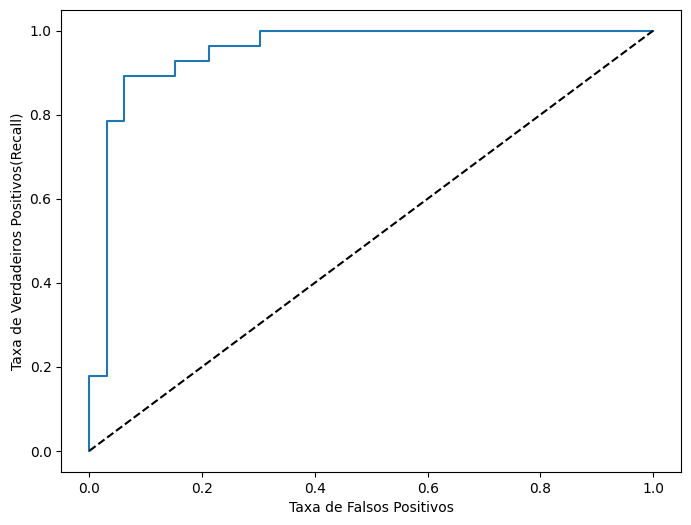

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos(Recall)')

plt.show()

Interpretação
|AUC|qualidade|
|:---|:---|
|0,5|Aléatório|
|0,6 - 0,7|Ruim|
|0,7 - 0,8|Ok|
|0,8 - 0,9|Bom|
|0,9 - 1,0|Exelente|

A curva ROC foi utilizada para avaliar o desempenho do modelo em diferentes limiares de decisão. A métrica AUC (Área sob a Curva) indica a capacidade do modelo em distinguir entre as classes. Valores mais próximos de 1 representam melhor desempenho discriminativo.